**Observações**:


*   **Envio de um txt com dois links: O primeiro link para um google docs com as respostas das questões que tem explicação teórica; O segundo link para um colab com as implementações solicitadas nas questões. Por favor, coloque a identificação correta das questões se for separar em dois arquivos.**


*   As questões onde é necessário codificar devem ser feitas na linguagem de programação **python**

**1 - Explique o que é vizinhaça N<sub>4</sub>(p), N<sub>D</sub>(p) e N<sub>8</sub>(p) de um pixel.**

**Resposta:**

Para um pixel $p=(x,y)$ em uma imagem discreta:

- **Vizinhança $N_4(p)$:** formada pelos pixels acima, abaixo, à esquerda e à direita: $(x-1,y)$, $(x+1,y)$, $(x,y-1)$ e $(x,y+1)$. São os vizinhos que compartilham uma aresta com $p$.
- **Vizinhança diagonal $N_D(p)$:** formada pelos quatro pixels diagonais: $(x-1,y-1)$, $(x-1,y+1)$, $(x+1,y-1)$ e $(x+1,y+1)$. Eles compartilham apenas um vértice com $p$.
- **Vizinhança $N_8(p)$:** união de $N_4(p)$ com $N_D(p)$, totalizando os oito pixels ao redor de $p$, quando eles existem dentro dos limites da imagem.

**2 - Considere um pixel p localizado nas coordenadas (x, y). Explique o conceito de conectividade 4, 8 e mista. Informe para cada tipo de conectividade, as coordenadas dos pixels que são considerados vizinhos.**

**Resposta:**

A conectividade define quando dois pixels pertencentes ao conjunto de interesse podem ser considerados ligados:

- **Conectividade-4:** usa apenas $N_4(p)$, isto é, $(x-1,y)$, $(x+1,y)$, $(x,y-1)$ e $(x,y+1)$. Pixels que se tocam somente pela diagonal não são conectados.
- **Conectividade-8:** usa $N_8(p)$, incluindo também $(x-1,y-1)$, $(x-1,y+1)$, $(x+1,y-1)$ e $(x+1,y+1)$. Assim, o contato diagonal também liga os pixels.
- **Conectividade mista (m):** usa os quatro vizinhos de $N_4(p)$ e admite um vizinho diagonal somente quando os dois pixels em $N_4(p)$ que ficam entre os dois não pertencem ao conjunto de interesse. Isso reduz ambiguidades causadas por múltiplos caminhos diagonais.

Em todos os casos, a conectividade é aplicada apenas aos pixels com o mesmo valor, ou pertencentes ao conjunto de valores escolhido para o objeto.

**3 - Para que serve a mensuração da distância entre pixels? Quais são as principais métricas para calcular a distância entre dois pixels?**

**Resposta:**

A distância entre pixels serve para medir a separação espacial entre pontos, objetos ou centróides. Ela é útil para agrupar regiões, encontrar o objeto mais próximo, medir deslocamentos, comparar formas e decidir se dois pixels pertencem à mesma estrutura.

Para $p=(x_1,y_1)$ e $q=(x_2,y_2)$, as principais métricas são:

- **Euclidiana:** $d_E(p,q)=\sqrt{(x_1-x_2)^2+(y_1-y_2)^2}$; corresponde à distância geométrica em linha reta.
- **City Block (Manhattan ou quarteirão):** $d_4(p,q)=|x_1-x_2|+|y_1-y_2|$; mede o caminho usando apenas movimentos horizontais e verticais.
- **Chessboard (xadrez):** $d_8(p,q)=\max(|x_1-x_2|,|y_1-y_2|)$; permite movimentos diagonais e mede o número mínimo de movimentos de um rei no xadrez.

4 - A visão computacional é uma área de ciência da computação que lida com a manipulação de imagens digitais por meio de algoritmos e técnicas computacionais. Uma das tarefas fundamentais nesse campo é a identificação e análise de componentes conectados em uma imagem. Nessa questão, explore essa tarefa, abordando desde a sua definição até a implementação prática do algoritmo:


a) Conceito de componentes conectados

*   Forneça uma compreensão clara de como são definidos e idetificados em uma imagem.
*   Use ilustrações e exemplos para explicar os componentes conectados.


b) Implementação do algortimo

*   Demonstre a implementação prática de um algoritmo para identificação e análise de componentes conectados em imagens binárias.
*   Apresente o código-fonte comentado, explicando cada etapa do processamento.
*   Ilustre a imagem de entrada e a imagem de saída com os componentes identificados.

Inclua também:

*   Escolha ou construa uma imagem binária de entrada contendo objetos em posições diagonais ou próximas entre si.
*   Execute o algoritmo utilizando conectividade-4 e depois conectividade-8.
*   Compare os resultados obtidos, indicando: o número de componentes conectados encontrados em cada caso; quais objetos foram agrupados ou separados em cada conectividade; uma breve explicação do motivo dessa diferença.

**Resposta:**

Um componente conectado é um conjunto máximo de pixels do objeto que podem ser alcançados uns a partir dos outros seguindo uma regra de vizinhança. Em uma imagem binária, normalmente os pixels brancos (valor 1) formam os objetos e os pixels pretos (valor 0) representam o fundo. O resultado é uma imagem rotulada, na qual cada componente recebe um rótulo inteiro diferente.

Na conectividade-4, o caminho pode avançar somente por arestas compartilhadas. Na conectividade-8, também pode avançar pelas diagonais. Portanto, dois objetos que apenas se tocam diagonalmente permanecem separados com conectividade-4, mas são agrupados com conectividade-8. A célula seguinte constrói uma imagem com objetos separados e objetos em contato diagonal, executa as duas conectividades e mostra as imagens rotuladas.

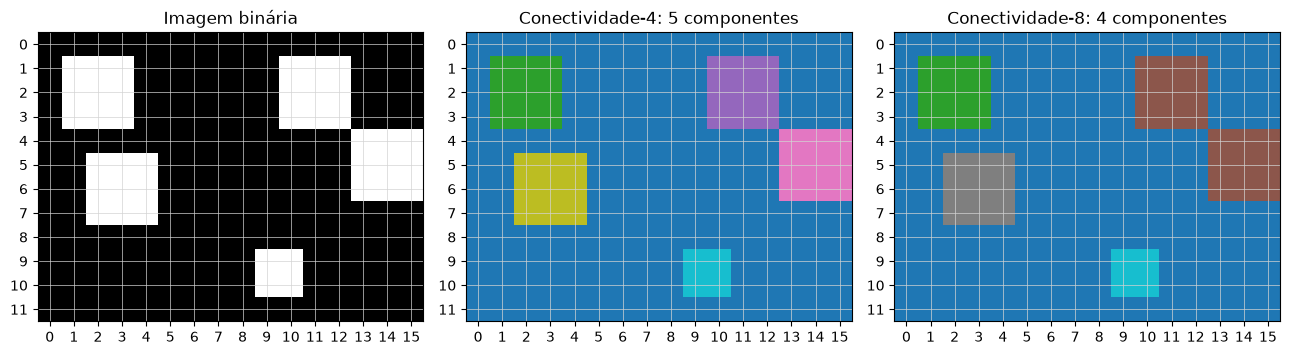

Conectividade-4: 5 componentes
Conectividade-8: 4 componentes
Os dois objetos que se tocam na diagonal são separados em 4 e agrupados em 8.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque


def rotular_componentes(imagem, conectividade=4):
    """Rotula pixels 1 usando conectividade-4 ou conectividade-8."""
    imagem = np.asarray(imagem, dtype=bool)
    rotulos = np.zeros(imagem.shape, dtype=int)
    if conectividade == 4:
        vizinhos = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    elif conectividade == 8:
        vizinhos = [
            (-1, 0), (1, 0), (0, -1), (0, 1),
            (-1, -1), (-1, 1), (1, -1), (1, 1)
        ]
    else:
        raise ValueError("A conectividade deve ser 4 ou 8.")

    proximo_rotulo = 0
    linhas, colunas = imagem.shape
    for linha in range(linhas):
        for coluna in range(colunas):
            if not imagem[linha, coluna] or rotulos[linha, coluna] != 0:
                continue
            proximo_rotulo += 1
            fila = deque([(linha, coluna)])
            rotulos[linha, coluna] = proximo_rotulo
            while fila:
                linha_atual, coluna_atual = fila.popleft()
                for deslocamento_linha, deslocamento_coluna in vizinhos:
                    nova_linha = linha_atual + deslocamento_linha
                    nova_coluna = coluna_atual + deslocamento_coluna
                    dentro_da_imagem = (
                        0 <= nova_linha < linhas and 0 <= nova_coluna < colunas
                    )
                    if (
                        dentro_da_imagem
                        and imagem[nova_linha, nova_coluna]
                        and rotulos[nova_linha, nova_coluna] == 0
                    ):
                        rotulos[nova_linha, nova_coluna] = proximo_rotulo
                        fila.append((nova_linha, nova_coluna))
    return rotulos


imagem_binaria = np.zeros((12, 16), dtype=np.uint8)
imagem_binaria[1:4, 1:4] = 1
imagem_binaria[5:8, 2:5] = 1
imagem_binaria[1:4, 10:13] = 1
imagem_binaria[4:7, 13:16] = 1
imagem_binaria[9:11, 9:11] = 1

rotulos_4 = rotular_componentes(imagem_binaria, conectividade=4)
rotulos_8 = rotular_componentes(imagem_binaria, conectividade=8)

figura, eixos = plt.subplots(1, 3, figsize=(13, 4))
eixos[0].imshow(imagem_binaria, cmap="gray", vmin=0, vmax=1)
eixos[0].set_title("Imagem binária")
eixos[1].imshow(rotulos_4, cmap="tab10", vmin=0)
eixos[1].set_title(f"Conectividade-4: {rotulos_4.max()} componentes")
eixos[2].imshow(rotulos_8, cmap="tab10", vmin=0)
eixos[2].set_title(f"Conectividade-8: {rotulos_8.max()} componentes")
for eixo in eixos:
    eixo.set_xticks(range(imagem_binaria.shape[1]))
    eixo.set_yticks(range(imagem_binaria.shape[0]))
    eixo.grid(color="lightgray", linewidth=0.5)
plt.tight_layout()
plt.show()

print("Conectividade-4:", rotulos_4.max(), "componentes")
print("Conectividade-8:", rotulos_8.max(), "componentes")
print("Os dois objetos que se tocam na diagonal são separados em 4 e agrupados em 8.")

5 - A identificação de componentes conectados em imagens binárias permite extrair propriedades geométricas importantes dos objetos presentes na imagem, como área, posição e centróide.

**Obs**: Existem variações da função de componentes conectados que retornam essas informações.

Considere uma imagem binária contendo dois objetos distintos:


a) Identificação dos componentes conectados

*   Aplique o algoritmo de componentes conectados para identificar os dois objetos presentes na imagem.
*   Apresente a imagem de entrada e a imagem rotulada.


b) Usando os centróides dos objetos encontrados, calcule a distância entre os dois objetos utilizando:

*   Distância Euclidiana.
*   Distância City Block (Quarteirão).
*   Distância Chessboard (Xadrez).

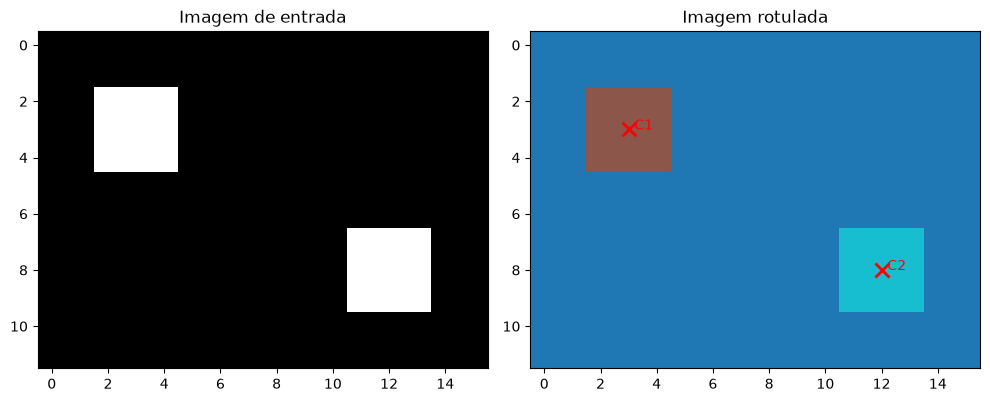

Componentes encontrados: 2
Centróides (x, y): [(np.float64(3.0), np.float64(3.0)), (np.float64(12.0), np.float64(8.0))]
Distância Euclidiana: 10.2956
Distância City Block: 14.0000
Distância Chessboard: 9.0000


In [2]:
imagem_dois_objetos = np.zeros((12, 16), dtype=np.uint8)
imagem_dois_objetos[2:5, 2:5] = 1
imagem_dois_objetos[7:10, 11:14] = 1

rotulos = rotular_componentes(imagem_dois_objetos, conectividade=8)
centroides = []
for rotulo in range(1, rotulos.max() + 1):
    coordenadas = np.argwhere(rotulos == rotulo)
    linha_media, coluna_media = coordenadas.mean(axis=0)
    centroides.append((coluna_media, linha_media))

ponto_1, ponto_2 = np.asarray(centroides[0]), np.asarray(centroides[1])
diferenca = np.abs(ponto_1 - ponto_2)
distancia_euclidiana = np.linalg.norm(ponto_1 - ponto_2)
distancia_city_block = diferenca.sum()
distancia_chessboard = diferenca.max()

figura, eixos = plt.subplots(1, 2, figsize=(10, 4))
eixos[0].imshow(imagem_dois_objetos, cmap="gray", vmin=0, vmax=1)
eixos[0].set_title("Imagem de entrada")
eixos[1].imshow(rotulos, cmap="tab10", vmin=0)
eixos[1].set_title("Imagem rotulada")
for indice, (coluna, linha) in enumerate(centroides, start=1):
    eixos[1].plot(coluna, linha, "rx", markersize=10, markeredgewidth=2)
    eixos[1].text(coluna + 0.2, linha, f"C{indice}", color="red")
plt.tight_layout()
plt.show()

print("Componentes encontrados:", rotulos.max())
print("Centróides (x, y):", centroides)
print(f"Distância Euclidiana: {distancia_euclidiana:.4f}")
print(f"Distância City Block: {distancia_city_block:.4f}")
print(f"Distância Chessboard: {distancia_chessboard:.4f}")

6 - Dado duas imagens em escala de cinza faça as seguintes operações aritméticas:

*   Soma
*   Subtração
*   Multiplicação
*   Divisão

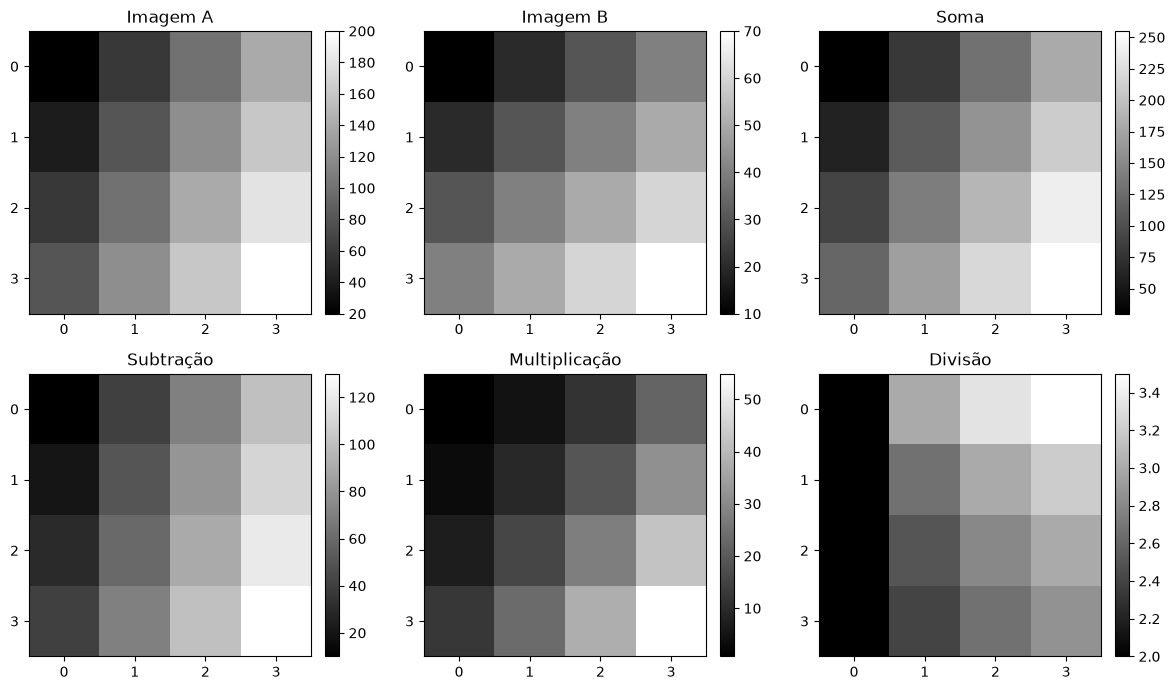

Soma:
 [[ 30.  80. 130. 180.]
 [ 60. 110. 160. 210.]
 [ 90. 140. 190. 240.]
 [120. 170. 220. 255.]]
Subtração:
 [[ 10.  40.  70. 100.]
 [ 20.  50.  80. 110.]
 [ 30.  60.  90. 120.]
 [ 40.  70. 100. 130.]]
Multiplicação normalizada:
 [[ 0.78431374  4.7058825  11.764706   21.960785  ]
 [ 3.137255    9.411765   18.82353    31.37255   ]
 [ 7.0588236  15.686275   27.450981   42.35294   ]
 [12.54902    23.529411   37.64706    54.901962  ]]
Divisão:
 [[2.        3.        3.3333333 3.5      ]
 [2.        2.6666667 3.        3.2      ]
 [2.        2.5       2.8       3.       ]
 [2.        2.4       2.6666667 2.857143 ]]


In [3]:
import numpy as np
import matplotlib.pyplot as plt

imagem_a = np.array([
    [20, 60, 100, 140],
    [40, 80, 120, 160],
    [60, 100, 140, 180],
    [80, 120, 160, 200]
], dtype=np.float32)
imagem_b = np.array([
    [10, 20, 30, 40],
    [20, 30, 40, 50],
    [30, 40, 50, 60],
    [40, 50, 60, 70]
], dtype=np.float32)

soma = np.clip(imagem_a + imagem_b, 0, 255)
subtracao = np.clip(imagem_a - imagem_b, 0, 255)
multiplicacao = np.clip(imagem_a * imagem_b / 255, 0, 255)
divisao = np.divide(imagem_a, imagem_b, out=np.zeros_like(imagem_a), where=imagem_b != 0)

resultados = [imagem_a, imagem_b, soma, subtracao, multiplicacao, divisao]
titulos = ["Imagem A", "Imagem B", "Soma", "Subtração", "Multiplicação", "Divisão"]
figura, eixos = plt.subplots(2, 3, figsize=(12, 7))
for eixo, resultado, titulo in zip(eixos.flat, resultados, titulos):
    imagem_exibida = eixo.imshow(resultado, cmap="gray")
    eixo.set_title(titulo)
    eixo.set_xticks(range(resultado.shape[1]))
    eixo.set_yticks(range(resultado.shape[0]))
    figura.colorbar(imagem_exibida, ax=eixo, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

print("Soma:\n", soma)
print("Subtração:\n", subtracao)
print("Multiplicação normalizada:\n", multiplicacao)
print("Divisão:\n", divisao)

7 - Escolha uma imagem em escala de cinza e realize as seguintes operações aritméticas usando um escalar de sua preferência:

*   Soma
*   Subtração
*   Multiplicação
*   Divisão

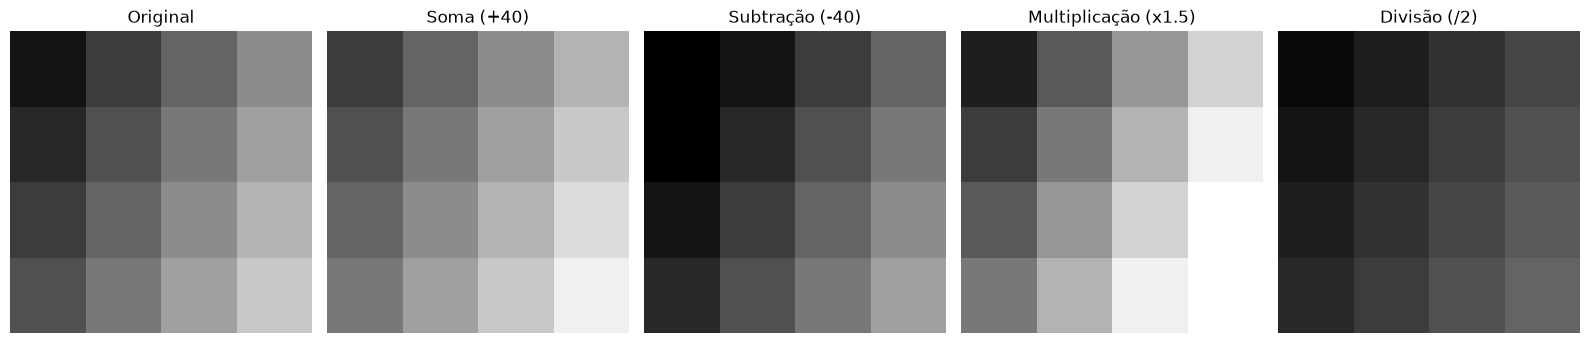

Escalar usado na soma/subtração: 40
Valores limitados ao intervalo [0, 255] para evitar overflow e subfaixas inválidas.


In [4]:
import numpy as np
import matplotlib.pyplot as plt

imagem = np.array([
    [20, 60, 100, 140],
    [40, 80, 120, 160],
    [60, 100, 140, 180],
    [80, 120, 160, 200]
], dtype=np.float32)
escalar = 40

soma_escalar = np.clip(imagem + escalar, 0, 255)
subtracao_escalar = np.clip(imagem - escalar, 0, 255)
multiplicacao_escalar = np.clip(imagem * 1.5, 0, 255)
divisao_escalar = imagem / 2

resultados = [imagem, soma_escalar, subtracao_escalar, multiplicacao_escalar, divisao_escalar]
titulos = ["Original", f"Soma (+{escalar})", f"Subtração (-{escalar})", "Multiplicação (x1.5)", "Divisão (/2)"]
figura, eixos = plt.subplots(1, 5, figsize=(16, 3.5))
for eixo, resultado, titulo in zip(eixos, resultados, titulos):
    eixo.imshow(resultado, cmap="gray", vmin=0, vmax=255)
    eixo.set_title(titulo)
    eixo.axis("off")
plt.tight_layout()
plt.show()

print("Escalar usado na soma/subtração:", escalar)
print("Valores limitados ao intervalo [0, 255] para evitar overflow e subfaixas inválidas.")

8 - Dado duas imagens binárias faça as seguintes operações lógicas:

*   And
*   Or
*   Not
*   Xor

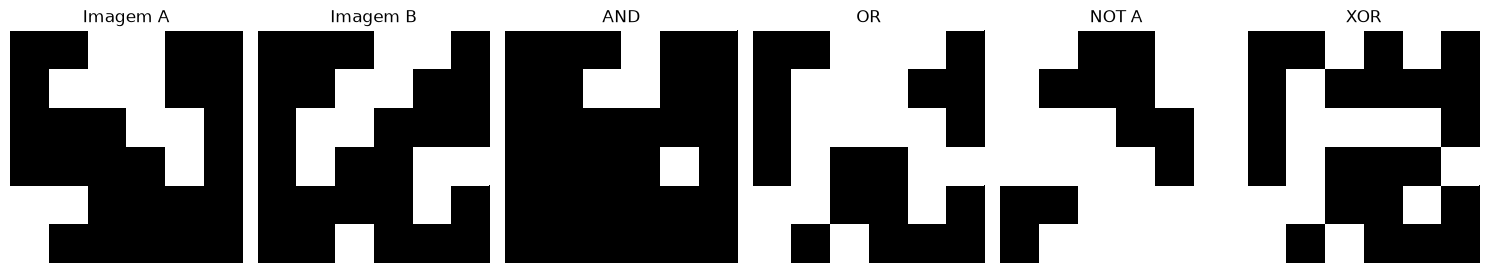

AND:
[[0 0 0 1 0 0]
 [0 0 1 1 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 1 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]]

OR:
[[0 0 1 1 1 0]
 [0 1 1 1 0 0]
 [0 1 1 1 1 0]
 [0 1 0 0 1 1]
 [1 1 0 0 1 0]
 [1 0 1 0 0 0]]

NOT A:
[[1 1 0 0 1 1]
 [1 0 0 0 1 1]
 [1 1 1 0 0 1]
 [1 1 1 1 0 1]
 [0 0 1 1 1 1]
 [0 1 1 1 1 1]]

XOR:
[[0 0 1 0 1 0]
 [0 1 0 0 0 0]
 [0 1 1 1 1 0]
 [0 1 0 0 0 1]
 [1 1 0 0 1 0]
 [1 0 1 0 0 0]]



In [5]:
import numpy as np
import matplotlib.pyplot as plt

imagem_binaria_a = np.array([
    [0, 0, 1, 1, 0, 0],
    [0, 1, 1, 1, 0, 0],
    [0, 0, 0, 1, 1, 0],
    [0, 0, 0, 0, 1, 0],
    [1, 1, 0, 0, 0, 0],
    [1, 0, 0, 0, 0, 0]
], dtype=bool)
imagem_binaria_b = np.array([
    [0, 0, 0, 1, 1, 0],
    [0, 0, 1, 1, 0, 0],
    [0, 1, 1, 0, 0, 0],
    [0, 1, 0, 0, 1, 1],
    [0, 0, 0, 0, 1, 0],
    [0, 0, 1, 0, 0, 0]
], dtype=bool)

operacoes_logicas = {
    "AND": np.logical_and(imagem_binaria_a, imagem_binaria_b),
    "OR": np.logical_or(imagem_binaria_a, imagem_binaria_b),
    "NOT A": np.logical_not(imagem_binaria_a),
    "XOR": np.logical_xor(imagem_binaria_a, imagem_binaria_b)
}

figura, eixos = plt.subplots(1, 6, figsize=(15, 3))
eixos[0].imshow(imagem_binaria_a, cmap="gray", vmin=0, vmax=1)
eixos[0].set_title("Imagem A")
eixos[1].imshow(imagem_binaria_b, cmap="gray", vmin=0, vmax=1)
eixos[1].set_title("Imagem B")
for eixo, (titulo, resultado) in zip(eixos[2:], operacoes_logicas.items()):
    eixo.imshow(resultado, cmap="gray", vmin=0, vmax=1)
    eixo.set_title(titulo)
for eixo in eixos:
    eixo.axis("off")
plt.tight_layout()
plt.show()

for titulo, resultado in operacoes_logicas.items():
    print(f"{titulo}:\n{resultado.astype(int)}\n")

9 - Em que situações práticas cada uma dessas operações lógicas seria útil?





**Resposta:**

- **AND:** mantém somente as regiões que estão presentes nas duas imagens. É útil na interseção de máscaras, por exemplo para selecionar uma área de interesse dentro de uma segmentação.
- **OR:** une as regiões presentes em pelo menos uma das imagens. É útil para combinar máscaras obtidas por métodos diferentes ou reunir objetos detectados em etapas distintas.
- **NOT:** inverte a imagem binária, transformando 0 em 1 e 1 em 0. É útil para obter o fundo a partir de uma máscara de objeto ou selecionar a região complementar.
- **XOR:** mantém os pixels que aparecem em exatamente uma das imagens. É útil para destacar diferenças entre duas máscaras, detectar alterações e comparar resultados de segmentação.

Essas operações são aplicadas pixel a pixel, desde que as imagens tenham as mesmas dimensões.